In [9]:
import kagglehub
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# ==========================================
# 1. データ準備 (レポート「2. データ準備」部分)
# ==========================================
print("Kaggleからデータをダウンロード中...")
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

fake_df = pd.read_csv(f"{path}/Fake.csv")
real_df = pd.read_csv(f"{path}/True.csv")
fake_df["label"] = 1 # Fake
real_df["label"] = 0 # Real

# テキストとラベルを取り出して結合
df = pd.concat([
    fake_df[["text", "label"]].dropna(),
    real_df[["text", "label"]].dropna()
], axis=0).reset_index(drop=True)

# ⭐️時間短縮のため、全体からランダムに2000件抽出
df = df.sample(2000, random_state=42)
texts = df["text"].astype(str).values
y = df["label"].astype(np.float32).values

# 単語をID化（トークナイズ）
def tokenize(text):
    return re.findall(r'\w+', text.lower())

vocab = Counter()
for text in texts:
    vocab.update(tokenize(text))

word2idx = {word: idx + 1 for idx, (word, _) in enumerate(vocab.most_common(3000))}
vocab_size = len(word2idx) + 1
max_len = 100 # 各記事の最初の100単語を使う

X_seq = np.zeros((len(texts), max_len), dtype=int)
for i, text in enumerate(texts):
    tokens = tokenize(text)
    seq = [word2idx.get(w, 0) for w in tokens[:max_len]]
    X_seq[i, :len(seq)] = seq

# PyTorchのテンソル（Tensor）に変換
X_tensor = torch.tensor(X_seq, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# 訓練・テストに分割
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y)
print(f"データ準備完了! Vocab size: {vocab_size}, Train: {len(X_train)}, Test: {len(X_test)}")

Kaggleからデータをダウンロード中...
Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
データ準備完了! Vocab size: 3001, Train: 1600, Test: 400


In [10]:
# ==========================================
# 2. PyTorch LSTMモデルの定義 (レポート「3. モデルの適用」部分)
# ==========================================
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        out = self.dropout(hidden[-1]) # LSTMの最後の出力を取得
        out = self.fc(out)
        return torch.sigmoid(out) # 0〜1の確率に変換

# GPUが使えるか確認
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TextLSTM(vocab_size, embed_dim=64, hidden_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.BCELoss() # 2値分類用の損失関数

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [11]:
# ==========================================
# 3. 学習の実行
# ==========================================
print(f"学習を開始します (Device: {device})")
epochs = 20
train_losses, test_losses, train_accs, test_accs = [], [], [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimizer.step()

    # 評価モード
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test)
        test_loss = criterion(test_preds, y_test)

        train_acc = accuracy_score(y_train.cpu(), (predictions.cpu() > 0.5).int())
        test_acc = accuracy_score(y_test.cpu(), (test_preds.cpu() > 0.5).int())

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc)
        test_accs.append(test_acc)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {loss.item():.4f} | Test Acc: {test_acc:.4f}")

学習を開始します (Device: cpu)
Epoch 05/20 | Train Loss: 0.6717 | Test Acc: 0.5525
Epoch 10/20 | Train Loss: 0.6152 | Test Acc: 0.5900
Epoch 15/20 | Train Loss: 0.4968 | Test Acc: 0.6800
Epoch 20/20 | Train Loss: 0.4355 | Test Acc: 0.7225


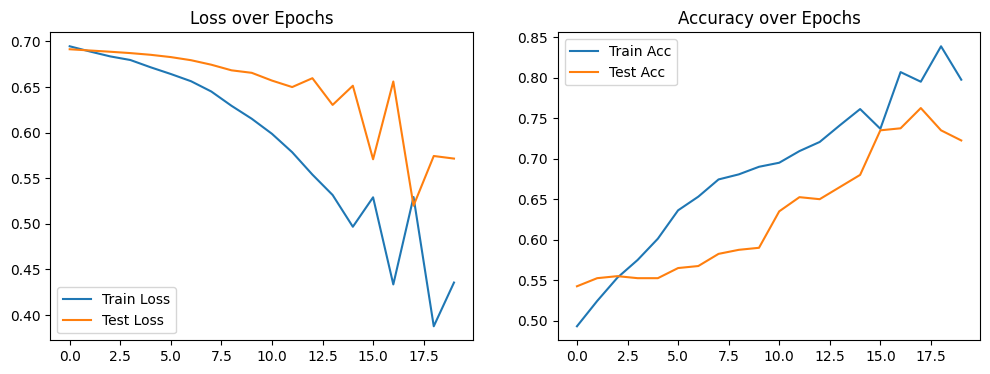

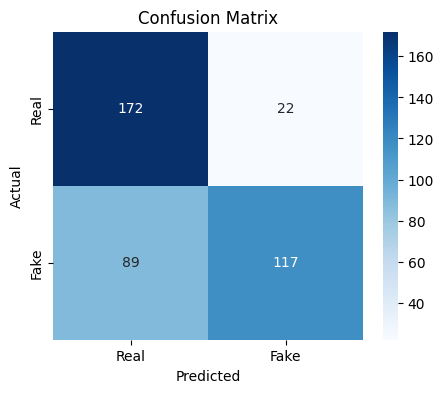

In [12]:
# ==========================================
# 4. 結果の可視化 (レポート「4. 結果と考察」部分)
# ==========================================
# 学習曲線の描画
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# 混同行列（Confusion Matrix）の描画
cm = confusion_matrix(y_test.cpu(), (test_preds.cpu() > 0.5).int())
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()